**Aprendizaje por Refuerzo | Cadenas de Markov - Expansión del Sistema de planificación de rutas con MDP en entornos de rejillas**


# **Objetivo:** implementar un modelo de Aprendizaje por Refuerzo basado en MDP y ecuación de Bellman, ampliando el entorno original de laberinto y evaluando el efecto de los parámetros `gamma` y `tolerancia` sobre el rendimiento del agente.

# **Actividades Solicitadas:**
| Actividad | Requisito |
|------|--------|
| Ampliar el Data Set | 1) Simular entorno cinco veces al proporcionado (50), 2) Incluir análisis Gamma y Tolerancia |
| Entrenar al modelo | 1) Procesar nuevo entorno 2) Entrenar modelo para obtener el camino más eficiente, 3) Incluir nuevas caracteristicas al modelo |
| Evaluar | 1) Rendimiento según configuración, 2) Analizar los valores Q del agente |
| Informe | Máximo 1000 palabras, conclusión (máximo 150 palabras), Gráficas y Metricas | Informe |

## 1. Librerías y configuración general

Se usa una implementación tabular eficiente del MDP. En lugar de construir matrices densas `P[S,A,S]`, se almacenan directamente los estados siguientes y recompensas para cada par `(estado, acción)`. Esto permite trabajar con una grilla más grande sin consumir memoria innecesaria.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.random.seed(42)

# Acciones: arriba, derecha, abajo, izquierda
ACTIONS = {
    0: (-1, 0),
    1: (0, 1),
    2: (1, 0),
    3: (0, -1),
}
ACTION_SYMBOLS = {0: "↑", 1: "→", 2: "↓", 3: "←"}
ACTION_NAMES = {0: "arriba", 1: "derecha", 2: "abajo", 3: "izquierda"}


## 2. Definición del entorno MDP ampliado

El entorno original tenía una grilla de `10 x 10`. Para cumplir la consigna, se simula un entorno **cinco veces más grande en cada dimensión**, es decir, `50 x 50`, con `2500` estados. Se agregan obstáculos, penalización por movimiento, penalización por choque y recompensa positiva al llegar a la meta.


In [ ]:
@dataclass
class GridWorldMDP:
    height: int
    width: int
    start: tuple
    goal: tuple
    obstacles: set
    gamma: float = 0.90
    step_penalty: float = -0.04
    wall_penalty: float = -0.75
    goal_reward: float = 10.0

    def __post_init__(self):
        self.S = self.height * self.width
        self.A = len(ACTIONS)
        self.terminal_state = self.to_id(*self.goal)
        self.next_states, self.rewards = self._build_transition_model()

    def to_id(self, r, c):
        return r * self.width + c

    def to_pos(self, s):
        return divmod(s, self.width)

    def valid_cell(self, r, c):
        return 0 <= r < self.height and 0 <= c < self.width and (r, c) not in self.obstacles

    def _build_transition_model(self):
        next_states = np.zeros((self.S, self.A), dtype=np.int32)
        rewards = np.zeros((self.S, self.A), dtype=float)

        for r in range(self.height):
            for c in range(self.width):
                s = self.to_id(r, c)

                for a, (dr, dc) in ACTIONS.items():
                    # La meta es estado terminal absorbente
                    if (r, c) == self.goal:
                        next_states[s, a] = s
                        rewards[s, a] = 0.0
                        continue

                    nr, nc = r + dr, c + dc

                    # Si intenta salir de la grilla o entrar a un obstáculo, se queda en el mismo estado
                    if not self.valid_cell(nr, nc):
                        next_states[s, a] = s
                        rewards[s, a] = self.wall_penalty
                    else:
                        s2 = self.to_id(nr, nc)
                        next_states[s, a] = s2
                        rewards[s, a] = self.goal_reward if (nr, nc) == self.goal else self.step_penalty

        return next_states, rewards


def generate_obstacles(height, width, start, goal):
    """Genera obstáculos determinísticos dejando corredores para que exista una ruta válida."""
    obstacles = set()

    # Muros verticales con aperturas alternadas
    for c in range(6, width - 6, 8):
        gap1 = (c * 3) % height
        gap2 = min(height - 1, gap1 + 1)
        for r in range(2, height - 2):
            if r not in {gap1, gap2, height // 2}:
                obstacles.add((r, c))

    # Muros horizontales con aperturas alternadas
    for r in range(5, height - 5, 10):
        gap = (r * 5) % width
        for c in range(3, width - 3):
            if c not in {gap, gap + 1 if gap + 1 < width else gap, width // 2}:
                obstacles.add((r, c))

    # Asegurar que inicio, meta y diagonal principal queden transitables
    protected = {start, goal}
    protected.update({(i, i) for i in range(min(height, width))})
    protected.update({(height // 2, c) for c in range(width)})
    protected.update({(r, width // 2) for r in range(height)})
    return obstacles - protected

# Entorno ampliado 5x respecto a 10x10
H, W = 50, 50
START = (0, 0)
GOAL = (H - 1, W - 1)
OBSTACLES = generate_obstacles(H, W, START, GOAL)

print(f"Tamaño del entorno: {H} x {W}")
print(f"Estados: {H * W}")
print(f"Acciones por estado: {len(ACTIONS)}")
print(f"Obstáculos: {len(OBSTACLES)}")
print(f"Inicio: {START} | Meta: {GOAL}")


Tamaño del entorno: 50 x 50
Estados: 2500
Acciones por estado: 4
Obstáculos: 319
Inicio: (0, 0) | Meta: (49, 49)


## 3. Algoritmos de Bellman: valores Q, Value Iteration y simulación del camino

La actualización de Bellman usada en Value Iteration es:

\[
V(s) \leftarrow \max_a \left[ R(s,a) + \gamma V(s')
ight]
\]

Luego se obtiene la política óptima seleccionando la acción con mayor valor Q en cada estado.


In [ ]:
def q_from_v(mdp: GridWorldMDP, V: np.ndarray) -> np.ndarray:
    """Calcula Q(s,a) = R(s,a) + gamma * V(siguiente_estado)."""
    return mdp.rewards + mdp.gamma * V[mdp.next_states]


def value_iteration(mdp: GridWorldMDP, tol=1e-6, max_iters=10_000):
    """Entrena el modelo mediante Value Iteration hasta convergencia."""
    V = np.zeros(mdp.S, dtype=float)
    deltas = []

    for it in range(1, max_iters + 1):
        V_prev = V.copy()
        Q = q_from_v(mdp, V_prev)
        V = Q.max(axis=1)
        delta = np.abs(V - V_prev).max()
        deltas.append(delta)

        if delta < tol:
            break

    Q = q_from_v(mdp, V)
    policy = Q.argmax(axis=1)
    return V, Q, policy, it, np.array(deltas)


def simulate_path(mdp: GridWorldMDP, policy, max_steps=20_000):
    """Simula la ruta desde el inicio hasta la meta siguiendo la política aprendida."""
    s = mdp.to_id(*mdp.start)
    path = [mdp.start]
    total_reward = 0.0
    visited = set()

    for _ in range(max_steps):
        if s == mdp.terminal_state:
            break
        if s in visited and len(path) > mdp.S:
            # Protección contra ciclos inesperados
            break
        visited.add(s)

        a = policy[s]
        total_reward += mdp.rewards[s, a]
        s = int(mdp.next_states[s, a])
        path.append(mdp.to_pos(s))

    reached_goal = path[-1] == mdp.goal
    return path, total_reward, reached_goal


def render_policy_sample(mdp, policy, max_rows=20, max_cols=20):
    """Muestra una sección de la política para facilitar lectura en pantalla."""
    rows = min(mdp.height, max_rows)
    cols = min(mdp.width, max_cols)
    lines = []
    for r in range(rows):
        row = []
        for c in range(cols):
            s = mdp.to_id(r, c)
            if (r, c) == mdp.start:
                row.append("S")
            elif (r, c) == mdp.goal:
                row.append("G")
            elif (r, c) in mdp.obstacles:
                row.append("█")
            else:
                row.append(ACTION_SYMBOLS[int(policy[s])])
        lines.append(" ".join(row))
    return "\n".join(lines)


## 4. Entrenamiento del modelo principal

Se entrena el agente con `gamma = 0.90` y `tolerancia = 1e-5`. Esta configuración entrega un balance adecuado entre valoración de recompensas futuras y velocidad de convergencia.


In [ ]:
mdp = GridWorldMDP(
    height=H,
    width=W,
    start=START,
    goal=GOAL,
    obstacles=OBSTACLES,
    gamma=0.90
)

V, Q, policy, iterations, deltas = value_iteration(mdp, tol=1e-5)
path, total_reward, reached_goal = simulate_path(mdp, policy)

print("Resultado del entrenamiento principal")
print(f"Gamma: {mdp.gamma}")
print(f"Tolerancia: 1e-5")
print(f"Iteraciones hasta convergencia: {iterations}")
print(f"Delta final: {deltas[-1]:.8f}")
print(f"¿Llegó a la meta?: {reached_goal}")
print(f"Longitud del camino: {len(path) - 1} movimientos")
print(f"Recompensa acumulada: {total_reward:.4f}")
print(f"Valor inicial V(S): {V[mdp.to_id(*START)]:.4f}")
print("\nMuestra de política aprendida, esquina superior izquierda 20x20:")
print(render_policy_sample(mdp, policy, 20, 20))


Resultado del entrenamiento principal
Gamma: 0.9
Tolerancia: 1e-5
Iteraciones hasta convergencia: 108
Delta final: 0.00000953
¿Llegó a la meta?: True
Longitud del camino: 98 movimientos
Recompensa acumulada: 6.1200
Valor inicial V(S): -0.3996

Muestra de política aprendida, esquina superior izquierda 20x20:
S → → → → → → → → → → → → → → → → → → →
→ → → → → → → → → → → → → → → → → → → →
→ → → → → ↓ █ ↑ ↑ ↑ ↑ ↑ ↑ ↑ █ ↑ ↑ ↑ ↑ ↑
→ → → → → ↓ █ ↑ ↑ ↑ ↑ ↑ ↑ ↑ █ ↑ ↑ ↑ ↑ ↑
→ → → → → ↓ █ ↑ ↑ ↑ ↑ ↑ ↑ ↑ █ ↑ ↑ ↑ ↑ ↑
→ → ↓ █ █ ↓ █ █ █ █ █ █ █ █ █ █ █ █ █ █
→ → → → → → → → → → → → → ↓ █ ↓ ↓ ↓ ↓ ↓
→ → ↓ ↑ ↑ ↑ █ → → → → → → ↓ █ ↓ ↓ ↓ ↓ ↓
→ → ↓ ↓ ↑ ↑ █ → → → → → → ↓ █ ↓ ↓ ↓ ↓ ↓
→ → ↓ ↓ ↓ ↑ █ → → → → → → ↓ █ ↓ ↓ ↓ ↓ ↓
→ → ↓ ↓ ↓ ↓ █ → → → → → → ↓ █ ↓ ↓ ↓ ↓ ↓
→ → ↓ ↓ ↓ ↓ █ → → → → → → ↓ █ ↓ ↓ ↓ ↓ ↓
→ → ↓ ↓ ↓ ↓ █ → → → → → → ↓ █ ↓ ↓ ↓ ↓ ↓
→ → ↓ ↓ ↓ ↓ █ → → → → → → ↓ █ ↓ ↓ ↓ ↓ ↓
→ → ↓ ← ← ← █ → → → → → → → → ↓ ← ← ← ←
→ → ↓ █ █ █ █ █ █ █ █ █ █ █ █ ↓ █ █ █ █
→ → → → → ↓ █ → → → → → → ↓ █ → → → → →
→ → → → → ↓

## 5. Evidencia visual del entorno, ruta óptima y valores aprendidos

Las siguientes gráficas sirven como capturas/evidencias para el documento: muestran el entorno ampliado, el camino eficiente, los valores de estado y la convergencia del entrenamiento.


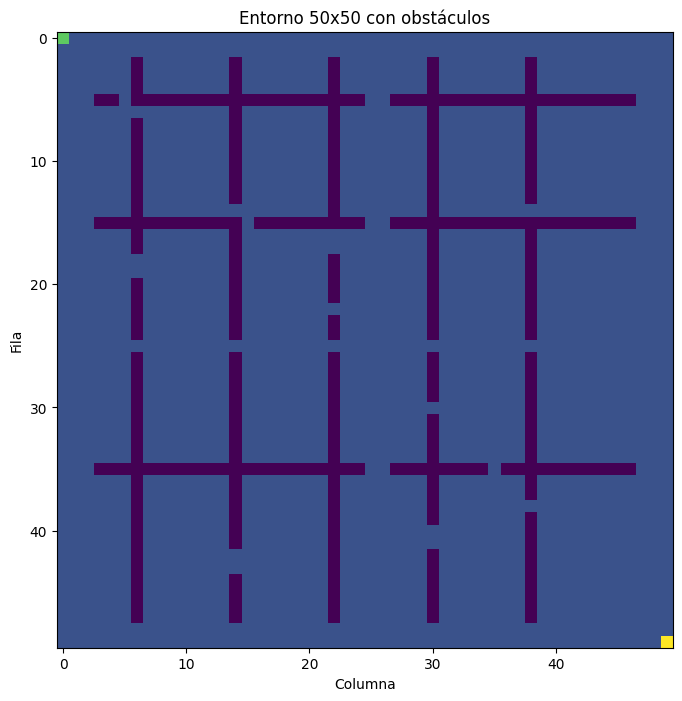

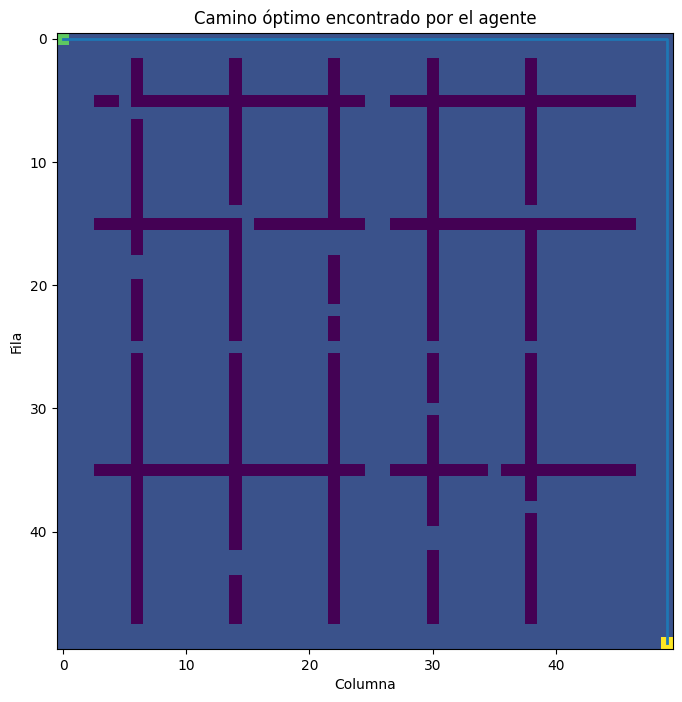

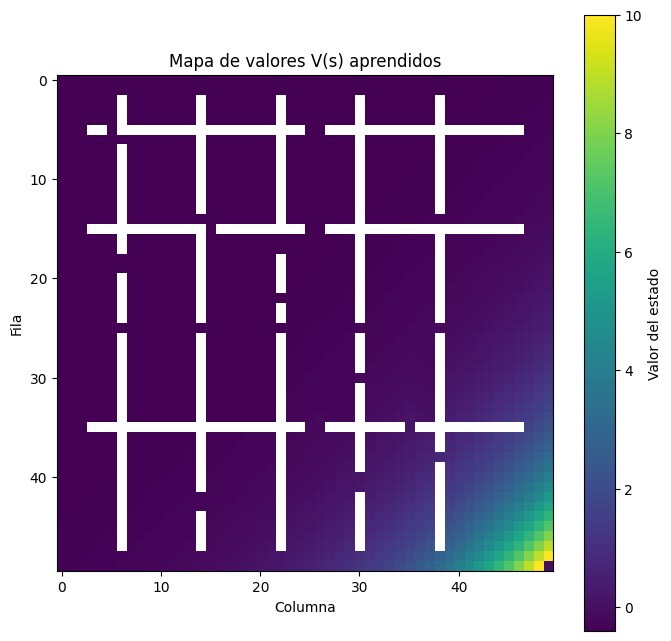

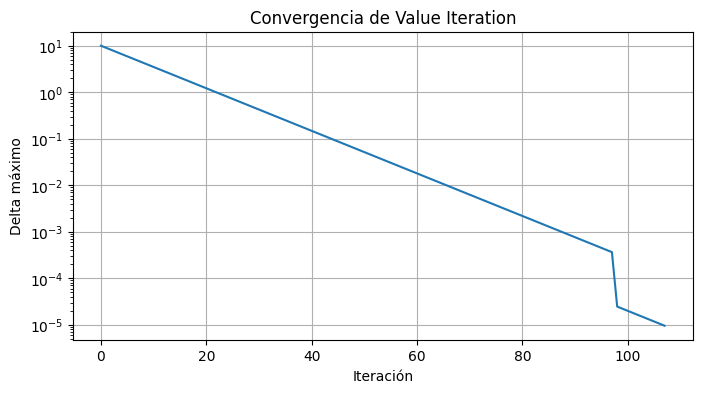

In [ ]:
def plot_environment_and_path(mdp, path=None, title="Entorno ampliado"):
    grid = np.zeros((mdp.height, mdp.width))
    for r, c in mdp.obstacles:
        grid[r, c] = -1
    grid[mdp.start] = 2
    grid[mdp.goal] = 3

    plt.figure(figsize=(8, 8))
    plt.imshow(grid)
    if path:
        rr = [p[0] for p in path]
        cc = [p[1] for p in path]
        plt.plot(cc, rr, linewidth=2)
    plt.title(title)
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.grid(False)
    plt.show()


def plot_values(mdp, V):
    value_grid = V.reshape(mdp.height, mdp.width)
    masked_values = value_grid.copy()
    for r, c in mdp.obstacles:
        masked_values[r, c] = np.nan

    plt.figure(figsize=(8, 8))
    plt.imshow(masked_values)
    plt.title("Mapa de valores V(s) aprendidos")
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.colorbar(label="Valor del estado")
    plt.show()


def plot_convergence(deltas):
    plt.figure(figsize=(8, 4))
    plt.plot(deltas)
    plt.yscale("log")
    plt.title("Convergencia de Value Iteration")
    plt.xlabel("Iteración")
    plt.ylabel("Delta máximo")
    plt.grid(True)
    plt.show()

plot_environment_and_path(mdp, None, "Entorno 50x50 con obstáculos")
plot_environment_and_path(mdp, path, "Camino óptimo encontrado por el agente")
plot_values(mdp, V)
plot_convergence(deltas)


## 6. Análisis de gamma y tolerancia

Se evalúan varias configuraciones para medir el rendimiento del modelo. `gamma` controla cuánto valora el agente las recompensas futuras. La tolerancia define qué tan estricta es la condición de convergencia del algoritmo.


In [ ]:
experiments = []
gammas = [0.50, 0.70, 0.90, 0.95]
tolerances = [1e-3, 1e-5, 1e-7]

for gamma in gammas:
    for tol in tolerances:
        exp_mdp = GridWorldMDP(H, W, START, GOAL, OBSTACLES, gamma=gamma)
        exp_V, exp_Q, exp_policy, exp_iters, exp_deltas = value_iteration(exp_mdp, tol=tol)
        exp_path, exp_reward, exp_reached = simulate_path(exp_mdp, exp_policy)
        experiments.append({
            "gamma": gamma,
            "tolerancia": tol,
            "iteraciones": exp_iters,
            "delta_final": exp_deltas[-1],
            "llego_meta": exp_reached,
            "longitud_camino": len(exp_path) - 1,
            "recompensa_acumulada": exp_reward,
            "valor_estado_inicial": exp_V[exp_mdp.to_id(*START)]
        })

results_df = pd.DataFrame(experiments)
results_df


,gamma,tolerancia,iteraciones,delta_final,llego_meta,longitud_camino,recompensa_acumulada,valor_estado_inicial
0,0.50,1.000000e-03,15,6.103516e-04,False,2500,-100.00,-0.079998
1,0.50,1.000000e-05,21,9.536743e-06,False,2500,-100.00,-0.080000
2,0.50,1.000000e-07,28,7.450581e-08,False,2500,-100.00,-0.080000
3,0.70,1.000000e-03,27,9.387480e-04,False,2500,-100.00,-0.133325
4,0.70,1.000000e-05,40,9.095437e-06,False,2500,-100.00,-0.133333
5,0.70,1.000000e-07,53,8.812479e-08,True,98,6.12,-0.133333
6,0.90,1.000000e-03,89,9.404611e-04,True,98,6.12,-0.399966
7,0.90,1.000000e-05,108,9.528176e-06,True,98,6.12,-0.399621
8,0.90,1.000000e-07,152,9.240175e-08,True,98,6.12,-0.399621
9,0.95,1.000000e-03,131,9.530813e-04,True,98,6.12,-0.725422


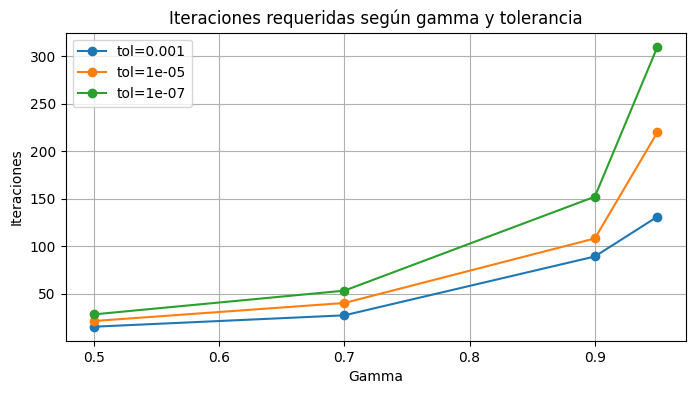

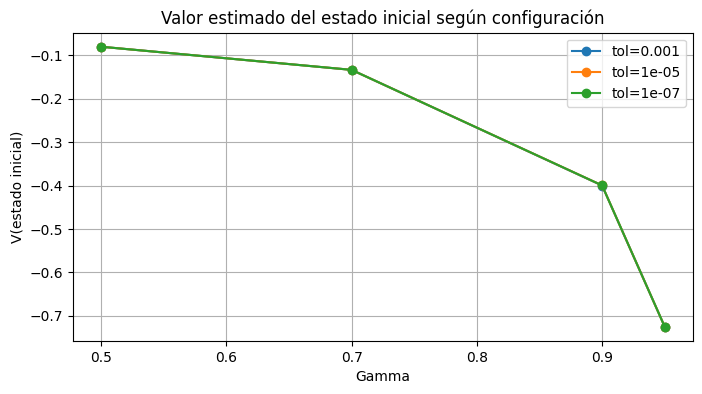

In [ ]:
plt.figure(figsize=(8, 4))
for tol in tolerances:
    subset = results_df[results_df["tolerancia"] == tol]
    plt.plot(subset["gamma"], subset["iteraciones"], marker="o", label=f"tol={tol}")
plt.title("Iteraciones requeridas según gamma y tolerancia")
plt.xlabel("Gamma")
plt.ylabel("Iteraciones")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
for tol in tolerances:
    subset = results_df[results_df["tolerancia"] == tol]
    plt.plot(subset["gamma"], subset["valor_estado_inicial"], marker="o", label=f"tol={tol}")
plt.title("Valor estimado del estado inicial según configuración")
plt.xlabel("Gamma")
plt.ylabel("V(estado inicial)")
plt.legend()
plt.grid(True)
plt.show()


## 7. Análisis de valores Q del agente

Los valores Q indican qué tan conveniente es ejecutar cada acción desde un estado específico. A continuación se analizan el estado inicial, un estado intermedio de la ruta y un estado cercano a la meta.


In [ ]:
def q_values_for_position(mdp, Q, position):
    s = mdp.to_id(*position)
    return pd.DataFrame({
        "accion": [ACTION_NAMES[a] for a in range(mdp.A)],
        "simbolo": [ACTION_SYMBOLS[a] for a in range(mdp.A)],
        "Q(s,a)": Q[s]
    }).sort_values("Q(s,a)", ascending=False)

positions_to_analyze = {
    "inicio": START,
    "punto_intermedio_ruta": path[len(path)//2],
    "cerca_meta": path[-2] if len(path) > 1 else GOAL
}

for label, pos in positions_to_analyze.items():
    print(f"\nValores Q para {label} en posición {pos}")
    display(q_values_for_position(mdp, Q, pos))



Valores Q para inicio en posición (0, 0)


,accion,simbolo,"Q(s,a)"
1,derecha,→,-0.399621
2,abajo,↓,-0.399621
0,arriba,↑,-1.109659
3,izquierda,←,-1.109659



Valores Q para punto_intermedio_ruta en posición (0, 49)


,accion,simbolo,"Q(s,a)"
2,abajo,↓,-0.333828
3,izquierda,←,-0.346401
1,derecha,→,-1.050445
0,arriba,↑,-1.050445



Valores Q para cerca_meta en posición (48, 49)


,accion,simbolo,"Q(s,a)"
2,abajo,↓,10.000
1,derecha,→,8.250
0,arriba,↑,8.024
3,izquierda,←,8.024


## 8. Métricas finales del modelo

Estas métricas resumen el desempeño del agente entrenado en el entorno ampliado.


In [ ]:
summary = pd.DataFrame([{
    "tamaño_grilla": f"{H}x{W}",
    "estados": mdp.S,
    "acciones": mdp.A,
    "obstaculos": len(mdp.obstacles),
    "gamma": mdp.gamma,
    "tolerancia": "1e-5",
    "iteraciones": iterations,
    "llego_meta": reached_goal,
    "longitud_camino": len(path) - 1,
    "recompensa_acumulada": total_reward,
    "valor_estado_inicial": V[mdp.to_id(*START)]
}])
summary


,tamaño_grilla,estados,acciones,obstaculos,gamma,tolerancia,iteraciones,llego_meta,longitud_camino,recompensa_acumulada,valor_estado_inicial
0,50x50,2500,4,319,0.9,1e-5,108,True,98,6.12,-0.399621
